## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
Already up to date.


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [3]:
import os, glob
import pandas as pd
import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import roc_auc_score

from Challenge.paths import generate_submission, load_xgboost_cv_folds, XGBOOST_DATAFRAMES
from Challenge.XGBoostNative import XGBoostNativeRecommender, ProgressCallback, EfficientRankerIterator

Running on local — storage at: /home/luigi/RecSys


## **Load Data**

In [4]:
# The columns you identified as highly correlated/redundant
DROP_COLS = [
    'ItemKNN_dice_Score', 'UserKNN_jaccard_Score', 'UserKNN_asymmetric_Score', 
    'UserKNN_asymmetric_RankPosition', 'UserKNN_tversky_Score', 'UserKNN_dice_Score', 
    'UserKNN_dice_RankPosition', 'UserKNN_dice_Recommended', 'EASE_R_Score', 
    'MatrixFactorization_WARP_RankPosition', 'Kurtosis_RankPosition', 
    'Item_Global_Popularity'
]

# The columns that are not features but metadata
META_COLS = ['UserID', 'ItemID', 'Label']
CATEGORICAL_COLS = ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']

INPUT_FILES = sorted(glob.glob(os.path.join(XGBOOST_DATAFRAMES, "ready_for_xgboost", "clean_part_*.parquet")))

print(f"Found {len(INPUT_FILES)} input files.")

Found 10 input files.


In [ ]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "validation_data.parquet")

df = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

# Extract Group Info
group_counts = df.groupby('UserID', sort=False).size().to_numpy()
y = df['Label']

# Stats for logging
n_rows = len(df)
n_groups = len(group_counts)

# Drop ID cols and Target
drop_cols = ['UserID', 'ItemID', 'Label'] # + DROP_COLS
X = df.drop(columns=drop_cols)

# Handle Categoricals
for col in CATEGORICAL_COLS:
    if col in X.columns:
        X[col] = X[col].astype('category')

In [6]:
dtrain = xgb.QuantileDMatrix(
    X,
    label=y,
    group=group_counts,
    enable_categorical=True
)

## **Train XG Boost**

In [ ]:
n_estimators   = 50
learning_rate  = 1e-1
reg_alpha      = 1e-1
reg_lambda     = 1e-1
max_depth      = 5
grow_policy    = "depthwise"
objective      = "pairwise"

params = {
    "objective": f"rank:{objective}",   # rank:pairwise
    "learning_rate": learning_rate,
    "reg_alpha": reg_alpha,
    "reg_lambda": reg_lambda,
    "max_depth": max_depth,
    "grow_policy": grow_policy,
    "max_leaves": 0,
    "booster": "gbtree",
    "verbosity": 1,
    "random_state": 42,
    "n_jobs": -1,

    "tree_method": "hist"
}


In [8]:
XGB_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=n_estimators,
    callbacks=[ProgressCallback(n_estimators)]
)

[Training] Tree 50/50

In [9]:
# Evaluate training performance
y_pred_scores = XGB_model.predict(dtrain)
y_train_true = dtrain.get_label()
auc_score = roc_auc_score(y_train_true, y_pred_scores)
print(f"Training AUC Score: {auc_score:.4f}")

Training AUC Score: 0.7997


## **Plots**

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

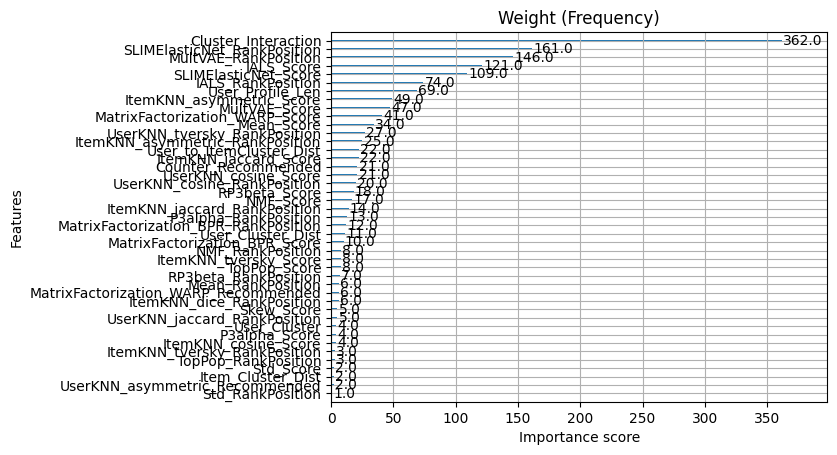

In [10]:
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')

<Axes: title={'center': 'Gain'}, xlabel='Importance score', ylabel='Features'>

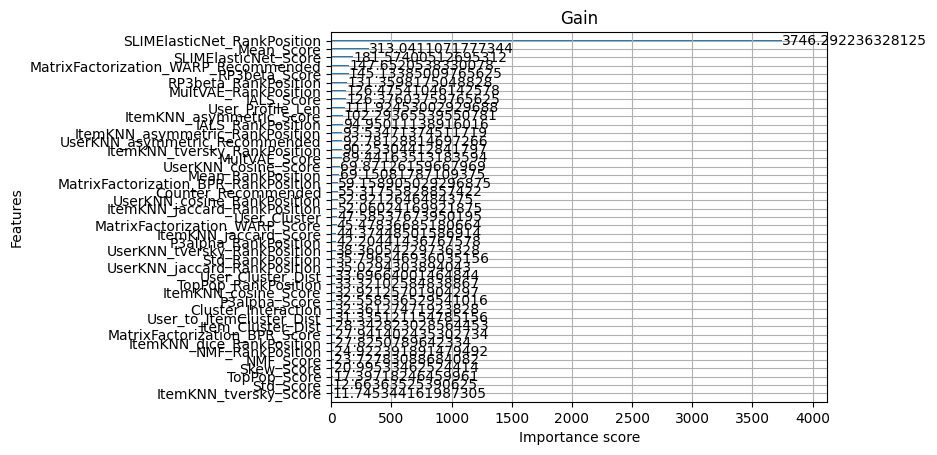

In [11]:
plot_importance(XGB_model, importance_type='gain', title='Gain')

<Axes: title={'center': 'Cover'}, xlabel='Importance score', ylabel='Features'>

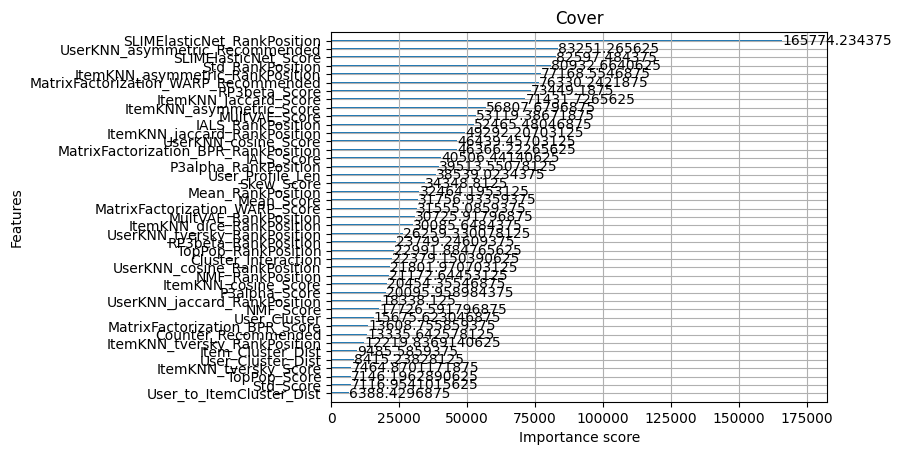

In [12]:
plot_importance(XGB_model, importance_type='cover', title='Cover')

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

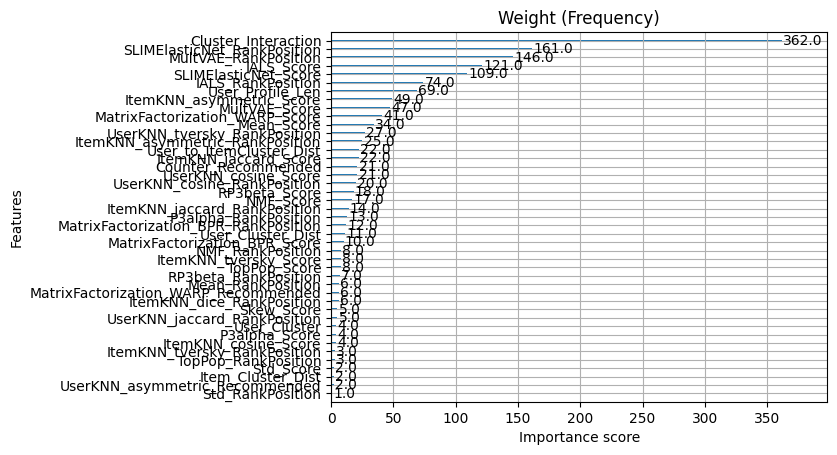

In [13]:
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')

## **Make prediction**

In [14]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "prediction_data.parquet")

X_pred = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
X_pred

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/prediction_data.parquet


,UserID,ItemID,TopPop_Score,TopPop_RankPosition,TopPop_Recommended,ItemKNN_cosine_Score,ItemKNN_cosine_RankPosition,ItemKNN_cosine_Recommended,ItemKNN_jaccard_Score,ItemKNN_jaccard_RankPosition,...,Mean_RankPosition,Std_RankPosition,Skew_RankPosition,Kurtosis_RankPosition,Mean_Score,Std_Score,Skew_Score,Kurtosis_Score,User_Profile_Len,Item_Global_Popularity
0,0,13,0.040529,1325,0,0.207680,545,0,0.129603,228,...,864.400024,707.630493,0.592600,-1.057776,0.079045,0.065471,0.427271,-1.248187,96,539
1,0,56,0.031657,1581,0,0.189687,618,0,0.023359,822,...,1818.800049,2450.433105,1.547447,0.564974,0.079662,0.097388,2.073433,4.319670,96,421
2,0,76,0.071208,820,0,0.415213,124,0,0.156571,183,...,211.000000,167.101608,2.677447,9.489000,0.178210,0.129551,1.451507,2.180224,96,947
3,0,86,0.316490,75,0,0.351859,194,0,0.099681,322,...,185.800003,202.099655,2.660424,8.649257,0.204315,0.144187,0.704453,-0.094114,96,4209
4,0,89,0.207234,188,0,0.504876,60,0,0.248379,82,...,163.600006,117.188286,2.385986,7.860408,0.194649,0.137918,0.859039,0.166705,96,2756
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8323808,27094,6899,0.005489,3668,0,0.139737,835,0,0.043833,770,...,1215.050049,1348.228394,2.998156,9.478342,0.117242,0.144279,1.838088,2.471816,314,73
8323809,27094,6920,0.030754,1536,0,0.219796,442,0,0.208459,116,...,421.600006,351.179291,1.763824,4.399051,0.181684,0.083786,-0.152094,-0.806321,314,409
8323810,27094,6941,0.141364,327,0,0.404935,119,0,0.273145,72,...,300.850006,621.634216,4.161278,17.983208,0.276996,0.167063,0.501362,0.499892,314,1880
8323811,27094,6942,0.008046,3112,0,0.125408,934,0,0.053615,652,...,1035.099976,636.775574,1.855995,5.262992,0.082957,0.077011,2.298047,5.538863,314,107


In [ ]:
# Drop cols
# X_pred = X_pred.drop(columns=DROP_COLS)

In [16]:
recommender = XGBoostNativeRecommender(
    XGB_model=XGB_model,
    df=X_pred
)

Indexing users...


In [18]:
generate_submission(recommender, "xg_boost_baseline_v2.csv")